In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings 
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns",None)

In [5]:
df = pd.read_csv("kaggle data/train.csv")
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


In [7]:
#data cleaning

features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]

for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100 , 5 ),'%missing values')

Artist Reputation 11.53846 %missing values
Height 5.76923 %missing values
Width 8.98462 %missing values
Weight 9.03077 %missing values
Material 11.75385 %missing values
Transport 21.41538 %missing values
Remote Location 11.86154 %missing values


In [8]:
#duplicate checking

df.duplicated().sum()

0

In [14]:
#Separate Numerical and Non-Numeric Features

target_feature = "Cost"

#define numerical and catogerical values

numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]

numeric_features.remove(target_feature)

non_numeric_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"\nWe have {len(non_numeric_features)} non numeircal features: {non_numeric_features}")

We have 6 numerical features: ['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price']

We have 13 non numeircal features: ['Customer Id', 'Artist Name', 'Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location', 'Scheduled Date', 'Delivery Date', 'Customer Location']


In [22]:
#Fill Missing Values Temporarily

df1 = df.copy()
for i in numeric_features:
    df1[i].fillna(df1[i].median() , inplace = True)

In [23]:
!pip install statsmodels

     ---------------------------------------- 9.1/9.1 MB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 34.1/34.1 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 2.4 MB/s eta 0:00:00


In [26]:
import statsmodels.api as sm

for i in range(0,len(numeric_features)):
    x = df1.loc[: , df1.columns == numeric_features[i]]
    y = df1.Cost
    model = sm.OLS(x,y)
    results = model.fit()
    rsq = results.rsquared
    vif = round(1/(1-rsq) , 2)
    
    print(f"VIF of this {numeric_features[i]} column is : {vif}")

VIF of this Artist Reputation column is : 1.01
VIF of this Height column is : 1.01
VIF of this Width column is : 1.02
VIF of this Weight column is : 1.2
VIF of this Price Of Sculpture column is : 1.3
VIF of this Base Shipping Price column is : 1.01


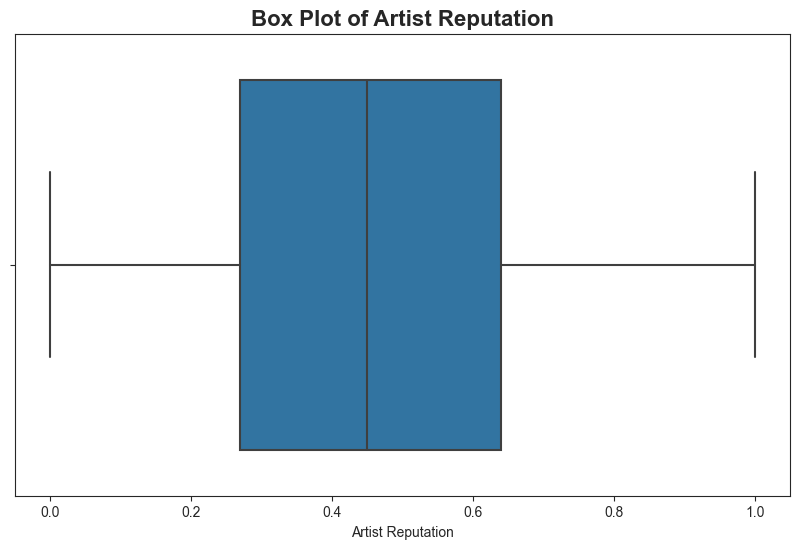

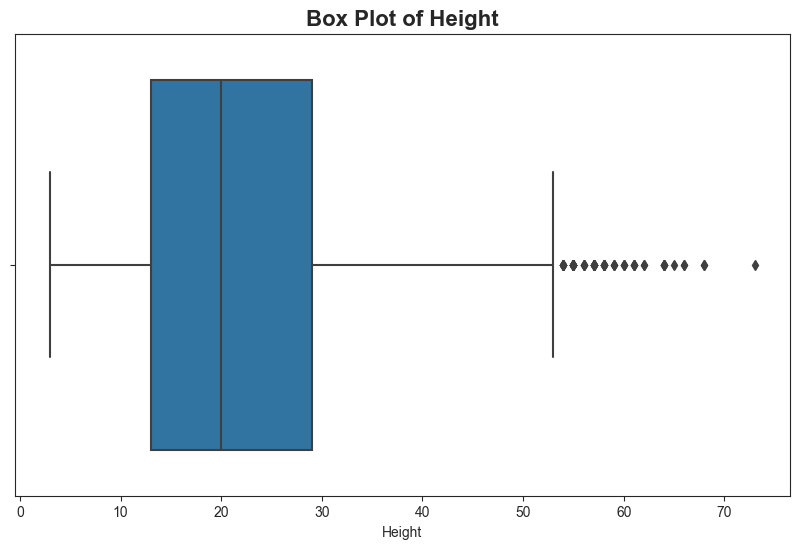

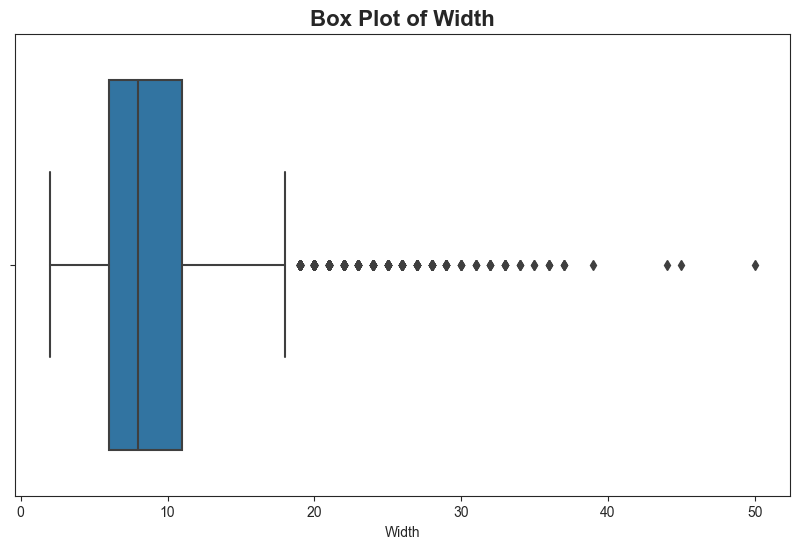

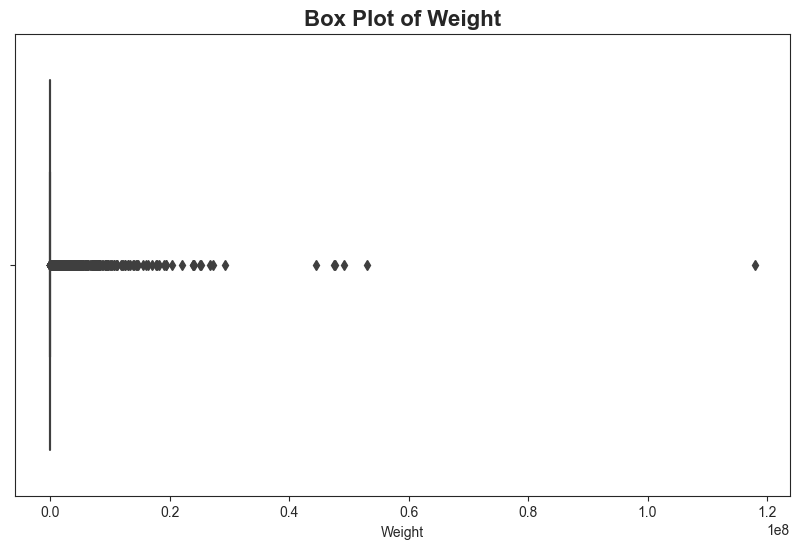

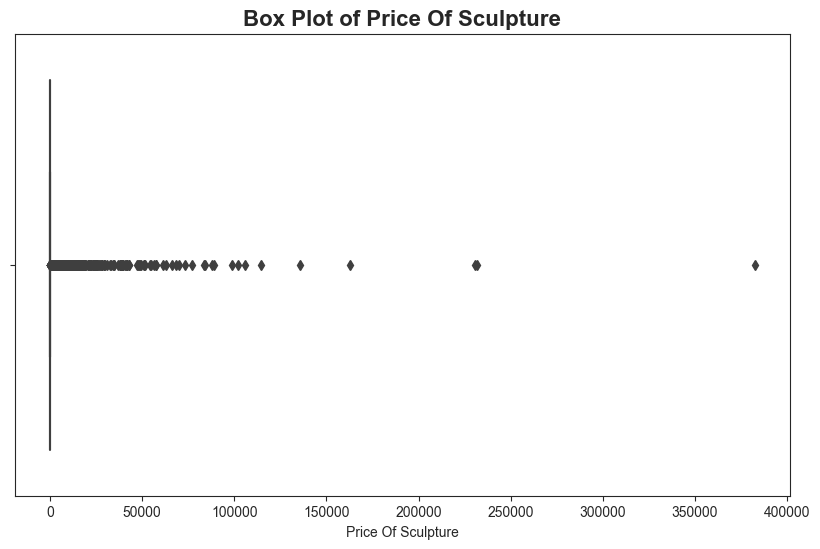

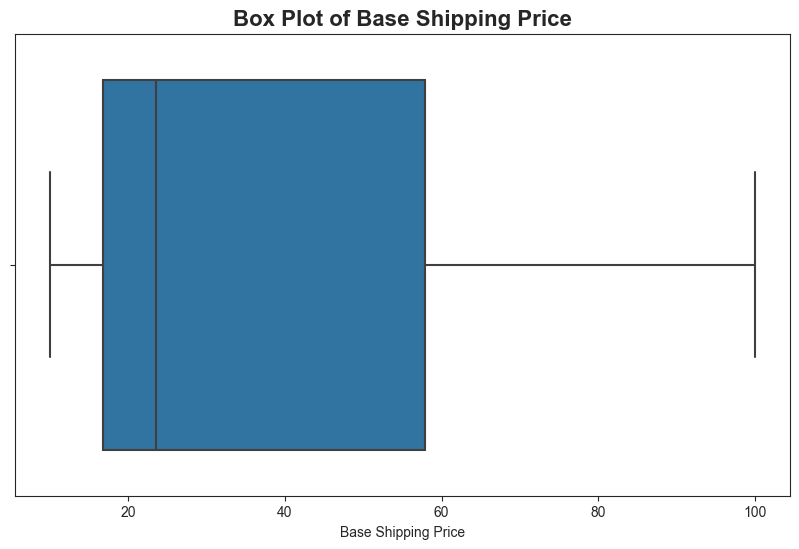

In [29]:
# Box Plots for Outlier Detection (Before Transformation)

for i in numeric_features:
    plt.figure(figsize=(10,6))
    sns.set_style('ticks')
    ax = sns.boxplot(x=df1[i])
    
    # Add this line to create a big, bold title for each graph!
    plt.title(f"Box Plot of {i}", fontsize=16, weight="bold")
    plt.show()

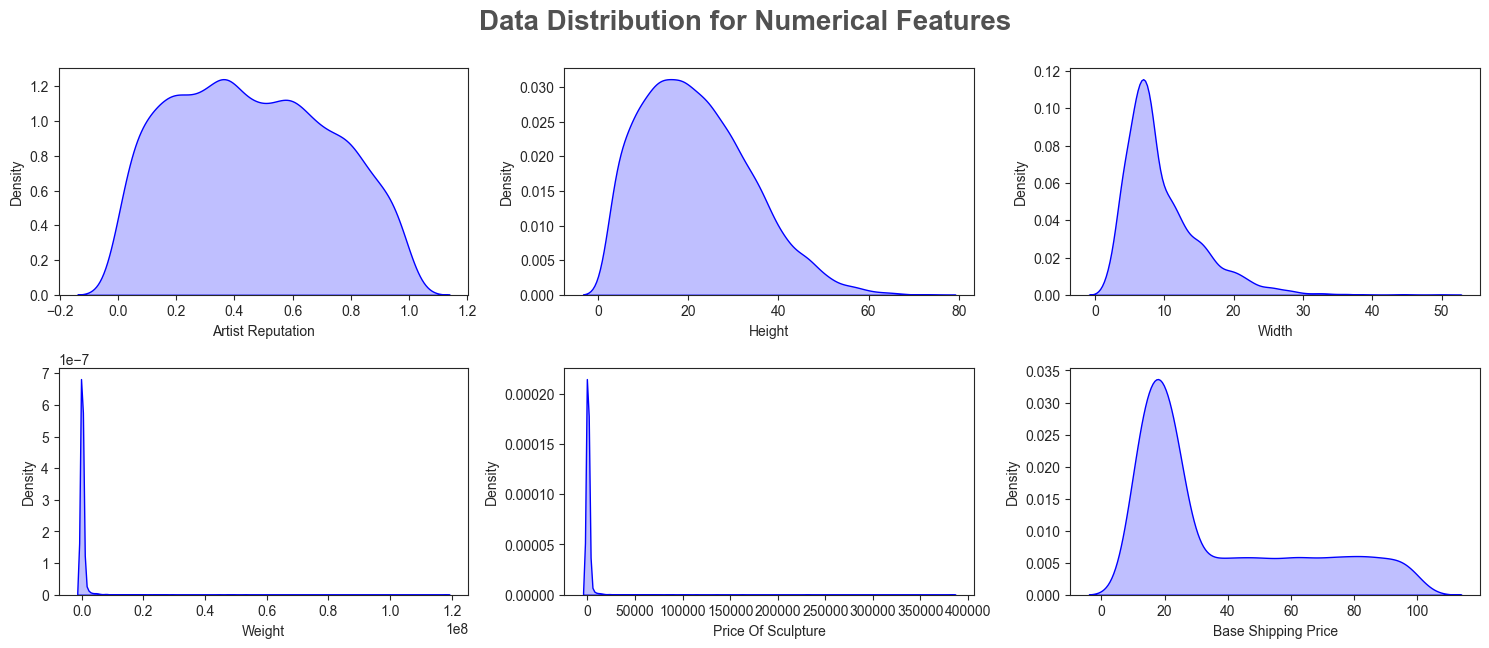

In [30]:
#KDE Plots for Data Distribution

plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]],shade=True, color='b')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

In [32]:
# Check Skewness

df[numeric_features].skew()

Artist Reputation       0.141363
Height                  0.594041
Width                   1.546702
Weight                 21.556174
Price Of Sculpture     22.206823
Base Shipping Price     0.918102
dtype: float64

In [45]:
#Checking the power transformer on outlier columns

outlier_feature = ['Price Of Sculpture', 'Weight']

In [46]:
#Initialize PowerTransformer

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(standardize=False)

outlier_data = df1[outlier_feature]

In [49]:
#activate powertransformer

df1[outlier_feature] = pt.fit_transform(df1[outlier_feature])

In [50]:
df_outlier = pd.DataFrame(outlier_data, columns = outlier_feature)

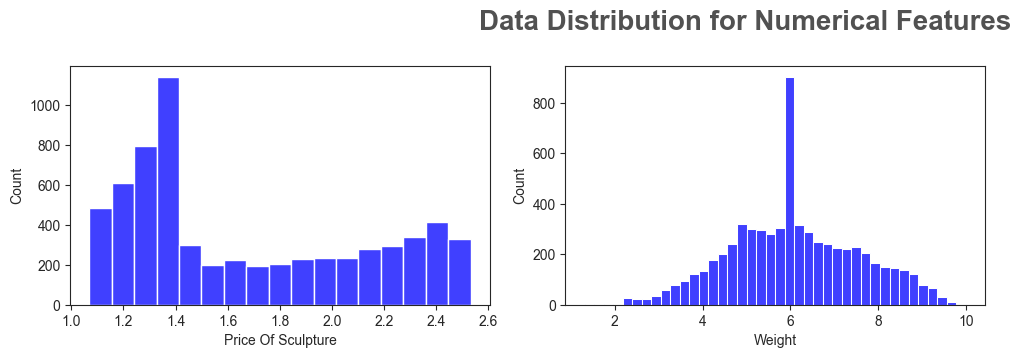

In [51]:
#Plot Transformed Data

plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(outlier_feature)):
    plt.subplot(5, 3, i+1)
    sns.histplot(x=df1[outlier_feature[i]], color='b')
    plt.xlabel(outlier_feature[i])
    plt.tight_layout()

In [52]:
#Check Skewness After Transformation

df1[outlier_feature].skew()

Price Of Sculpture    0.478648
Weight                0.027309
dtype: float64

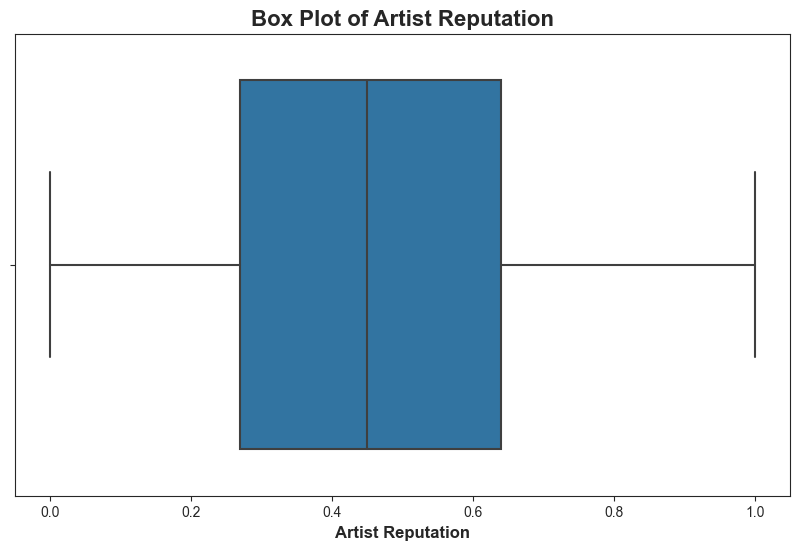

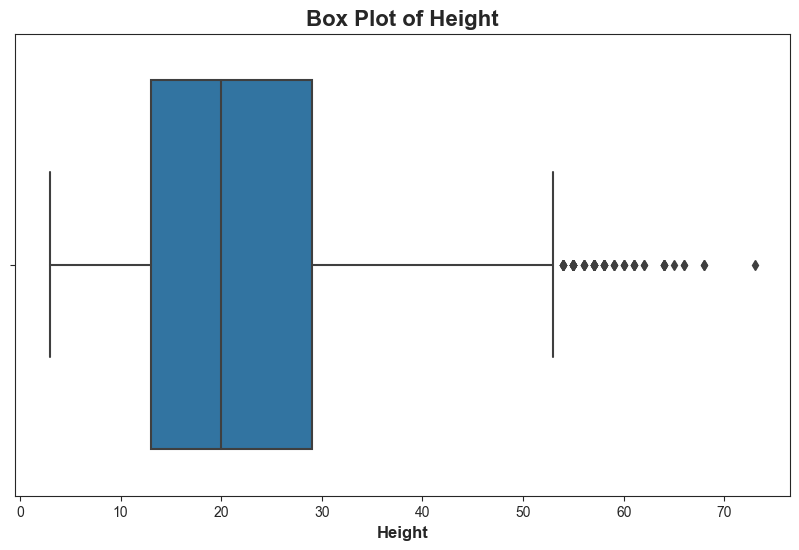

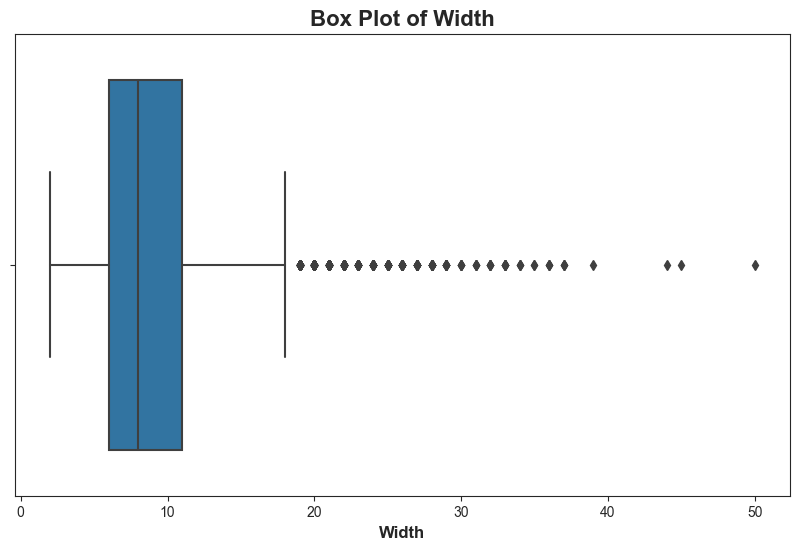

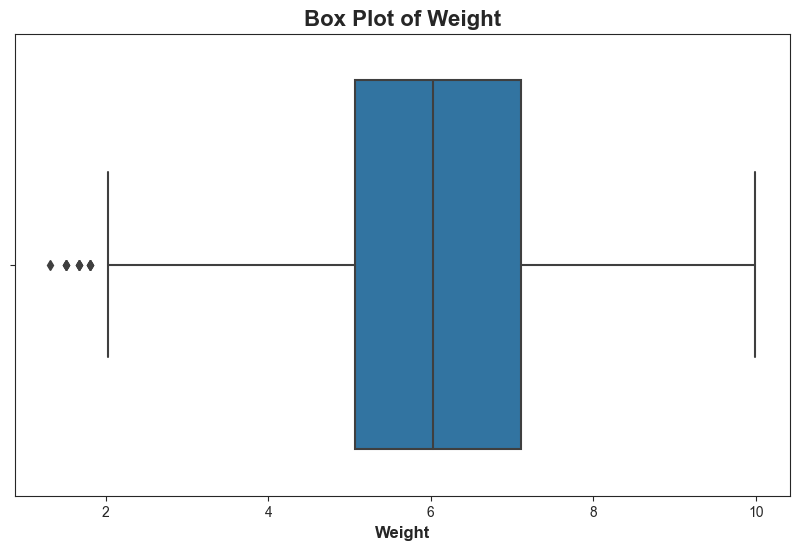

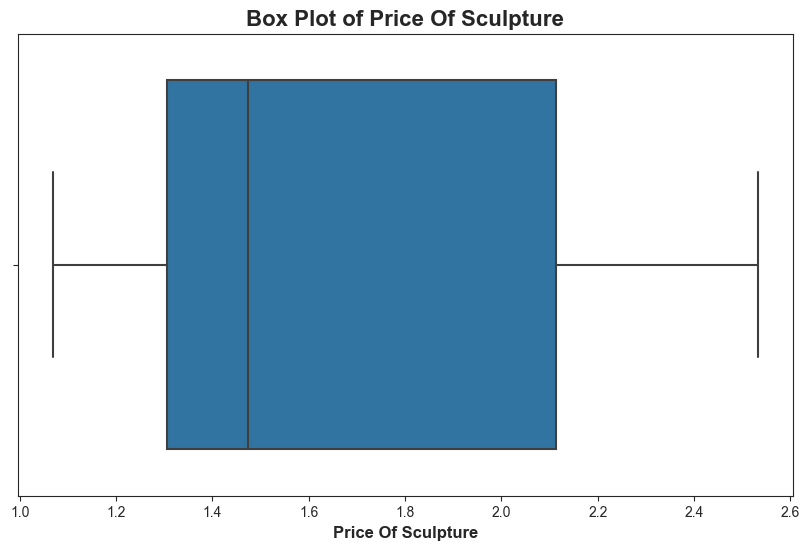

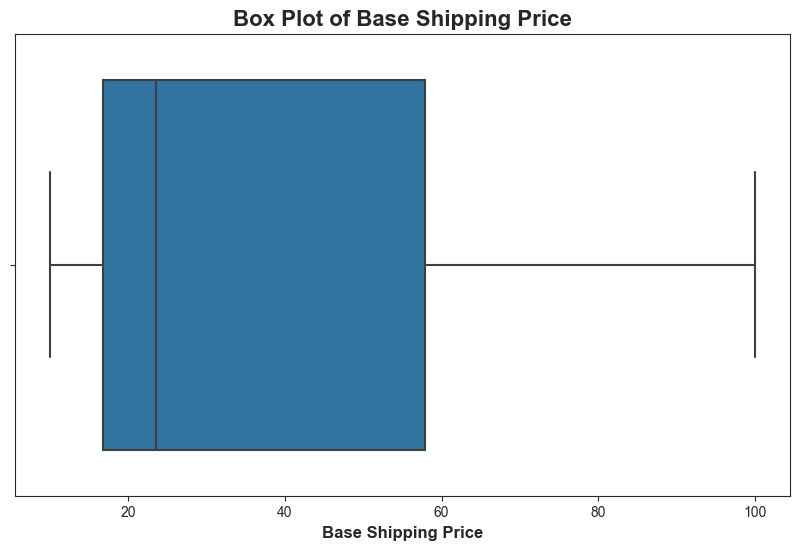

In [54]:
# Box Plots for Outlier Detection (Before Transformation)

for i in numeric_features:
    plt.figure(figsize=(10,6))
    sns.set_style('ticks')
    
    # Draw the box plot
    ax = sns.boxplot(x=df1[i])
    
    # Force the Top Title
    plt.title(f"Box Plot of {i}", fontsize=16, weight="bold")
    
    # Force the Column Name at the bottom (X-axis label)
    plt.xlabel(i, fontsize=12, weight="bold")
    
    plt.show()
    

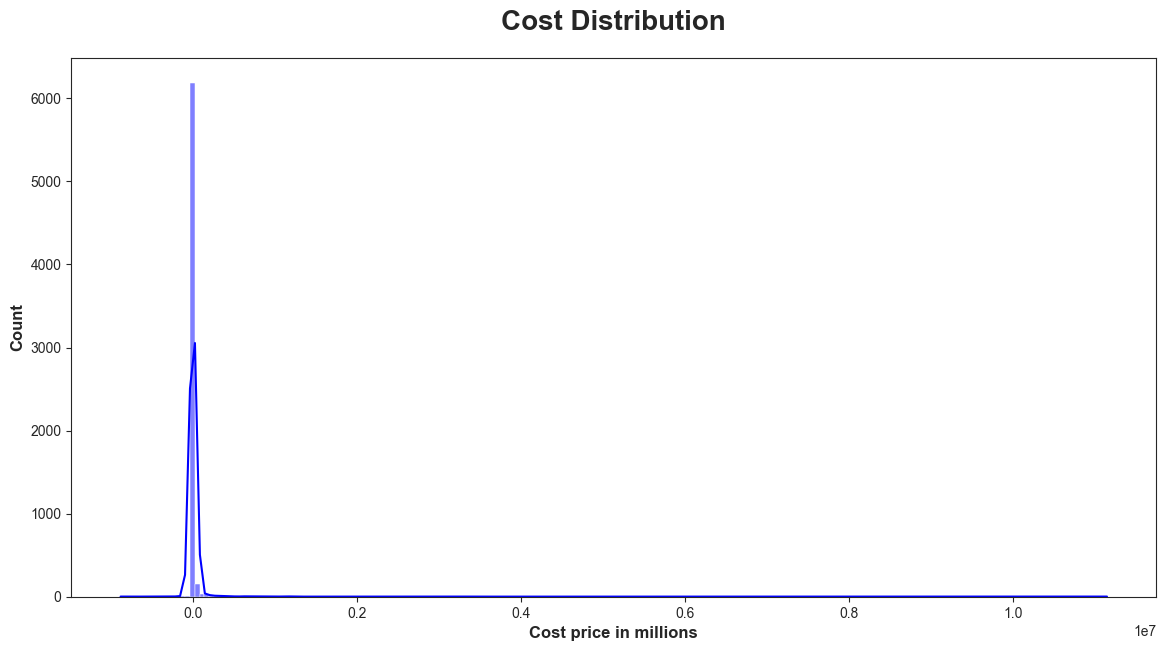

In [55]:
#Removing outliers from Target Column

#Cost Distribution Before Log Transform

plt.subplots(figsize=(14,7))
sns.histplot(df['Cost'], bins=200, kde=True, color = 'b')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.show()

In [56]:
#Log Transform the Target

df1["Cost"] = np.log1p(np.absolute(df1["Cost"]))

(array([2210., 2207., 1046.,  520.,  244.,  143.,   73.,   35.,   16.,
           6.]),
 array([ 4.46671239,  5.64267721,  6.81864203,  7.99460685,  9.17057167,
        10.34653649, 11.5225013 , 12.69846612, 13.87443094, 15.05039576,
        16.22636058]),
 <BarContainer object of 10 artists>)

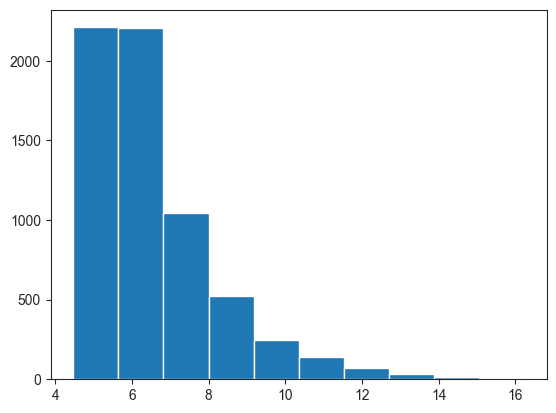

In [58]:
plt.hist(df1["Cost"])

In [59]:
#Convert Dates to Datetime

# Convert object datatype to datetime
df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])

In [60]:
#Extract Month and Year

df["Month"] = pd.to_datetime(df["Scheduled Date"]).dt.month
df["Year"] = pd.to_datetime(df["Scheduled Date"]).dt.year

numeric_features.append("Month")
numeric_features.append("Year")

In [61]:
#Define Columns to Drop

to_drop_columns = ['Customer Id', 'Artist Name', 'Customer Location', 'Scheduled Date', 'Delivery Date']

In [62]:
#Drop the Columns

df.drop(columns = to_drop_columns , inplace = True)

In [63]:
df.head()

,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Cost,Month,Year
0,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,-283.29,6,2015
1,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,-159.96,3,2017
2,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,-154.29,3,2015
3,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,-161.16,5,2015
4,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,-159.23,12,2016


In [68]:
!pip install catboost==1.1.1 xgboost==1.6.2

   ---------------------------------------- 73.9/73.9 MB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 125.4/125.4 MB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 47.0/47.0 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 15.6/15.6 MB 2.3 MB/s eta 0:00:00


In [69]:
#importing all the ml librarires

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, LabelEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

In [70]:
#Separate Features and Target

X = df.drop(columns = ["Cost"], axis = 1)
y = np.abs(df["Cost"])

In [71]:
#Log Transform the Target
y = np.log1p(y)

In [73]:
#Train test splits

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [74]:
#Feature Encoding and Scaling

numeric_features = [x for x in numeric_features if x not in outlier_feature]
catogerical_features = [x for x in non_numeric_features if x not in to_drop_columns]

(numeric_features), (catogerical_features), (outlier_feature)

(['Artist Reputation',
  'Height',
  'Width',
  'Base Shipping Price',
  'Month',
  'Year'],
 ['Material',
  'International',
  'Express Shipment',
  'Installation Included',
  'Transport',
  'Fragile',
  'Customer Information',
  'Remote Location'],
 ['Price Of Sculpture', 'Weight'])

In [77]:
#building the processing pipelines 

numeric_features_pipeline = Pipeline(steps = [("imputer", SimpleImputer(strategy = "mean")) , ("scaler", RobustScaler())])

catogerical_features_pipeline = Pipeline(steps = [("imputer", SimpleImputer(strategy = "most_frequent")), ("onehotencoder", OneHotEncoder())])

outlier_features_pipeline = Pipeline(steps = [("imputer", SimpleImputer(strategy = "median")), ("Powertransformer", PowerTransformer(standardize = True))])

preprocessor = ColumnTransformer([("Numeric pipeline" , numeric_features_pipeline, numeric_features), ("Catogerical pipeline", catogerical_features_pipeline, catogerical_features), ("Outlier pipeline", outlier_features_pipeline, outlier_features)])

In [78]:
#Apply Preprocessing

X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

In [79]:
#Model Selection

## functions which takes true and predicted values to calculate metrics

def evaluate_reg(true , predicted):
    
    mae = mean_absolute_error(true , predicted)
    
    mse = mean_squared_error(true , predicted)
    
    rmse = np.sqrt(mean_squared_error(true , predicted))
    
    r2_square = r2_score(true , predicted)
    
    return mae, rmse, r2_square

In [88]:
#Model Evaluation Function

## function which can evaluate models and return a report 

def evaluate_models(X_train, X_test , y_train , y_test , models):
    
    models_list = []
    r2_list = []
    
    for i in range(0,len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) #train model
        
        #make predictions
        y_train_pred = model.predict(X_train)
        
        y_test_pred = model.predict(X_test)
        
        #evaluate test and training dataset
        
        model_train_mae , model_train_rmse , model_train_r2 = evaluate_reg(y_train, y_train_pred)
        
        model_test_mae , model_test_rmse , model_test_r2 = evaluate_reg(y_test , y_test_pred)
        
        #printing the results on the screeen
        
        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])
        
        
        print('Model performance for Training set')
        print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
        print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
        print("- R2 Score: {:.4f}".format(model_train_r2))

        print('----------------------------------')

        print('Model performance for Test set')
        print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
        print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
        print("- R2 Score: {:.4f}".format(model_test_r2))
        r2_list.append(model_test_r2)

        print('='*35)
        print('\n')
        
        
    #building the final report
    report = pd.DataFrame(list(zip(models_list, r2_list)), columns = ["Model Name", "r2_score"]).sort_values(by = ["r2_score"], ascending = False)
    return report

In [89]:
#initialize the models req for the model

models = {
    "Linear Regression": LinearRegression(),
    "K-Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False, max_depth=5),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "SVR": SVR()
}

In [90]:
base_report = evaluate_models(X_train, X_test, y_train, y_test, models)

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.7361
- Mean Absolute Error: 0.4986
- R2 Score: 0.8012
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6963
- Mean Absolute Error: 0.4849
- R2 Score: 0.8219


K-Neighbors
Model performance for Training set
- Root Mean Squared Error: 0.5675
- Mean Absolute Error: 0.3614
- R2 Score: 0.8818
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.6588
- Mean Absolute Error: 0.4263
- R2 Score: 0.8406


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.5363
- Mean Absolute Error: 0.3330
- R2 Score: 0.8944


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1249
- Mean Absolute Error: 0.0799
- R2 Score: 0.9943
-------

In [91]:
base_report

,Model Name,r2_score
5,CatBoosting Regressor,0.971792
4,XGBRegressor,0.958326
3,Random Forest Regressor,0.954895
7,SVR,0.913033
2,Decision Tree,0.894354
6,AdaBoost Regressor,0.862026
1,K-Neighbors,0.840555
0,Linear Regression,0.821924


In [96]:
#Define Parameter Grids

#Initialize few parameter for Hyperparamter tuning
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

cat_params = {"learning_rate": [0.1, 0.01, 0.6, 0.5],
              "max_depth": [4, 5, 6, 8, 12]}

In [97]:
# Models list for Hyperparameter tuning

randomcv_models = [("RF", RandomForestRegressor(), rf_params), ("XGBoost", XGBRegressor(), xgboost_params), ("CatBoost", CatBoostRegressor(verbose = False), cat_params)]

In [101]:
#Run randomizedsearch cv

from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator = model, param_distributions = params, n_iter = 100, cv = 3, verbose = 2, n_jobs = 1)
    
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_
    
for model_name in model_param:
    print(f"-----------------Best params for {model_name} ------------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=10, max_features=5, min_samples_split=15, n_estimators=200; total time=   0.4s
[CV] END max_depth=10, max_features=5, min_samples_split=15, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=5, min_samples_split=15, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=15, max_features=8, min_samples_split=20, n_estimators=1000; total time=   2.6s
[CV] END max_depth=15, max_features=8, min_samples_split=20, n_estimators=1000; total time=   2.6s
[CV] END max_depth=15, max_features=8, min_samples_split=20, n_estimators=1000; total time=   3.0s
[CV] END max_depth=5, max_features=5, min_samples_split

[CV] END max_depth=10, max_features=8, min_samples_split=15, n_estimators=1000; total time=   2.4s
[CV] END max_depth=10, max_features=8, min_samples_split=15, n_estimators=1000; total time=   2.5s
[CV] END max_depth=10, max_features=8, min_samples_split=15, n_estimators=1000; total time=   2.5s
[CV] END max_depth=None, max_features=7, min_samples_split=15, n_estimators=500; total time=   1.2s
[CV] END max_depth=None, max_features=7, min_samples_split=15, n_estimators=500; total time=   1.2s
[CV] END max_depth=None, max_features=7, min_samples_split=15, n_estimators=500; total time=   1.2s
[CV] END max_depth=8, max_features=auto, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=8, max_features=auto, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=8, max_features=auto, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=5, max_features=auto, min_samples_split=8, n_estimators=100; total time=   0.4s
[CV] EN

[CV] END max_depth=15, max_features=5, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=5, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=5, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=5, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=8, min_samples_split=2, n_estimators=500; total time=   2.2s
[CV] END max_depth=None, max_features=8, min_samples_split=2, n_estimators=500; total time=   2.2s
[CV] END max_depth=None, max_features=8, min_samples_split=2, n_estimators=500; total time=   2.2s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=10, max_features=8, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_de

[CV] END max_depth=None, max_features=8, min_samples_split=8, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=7, min_samples_split=8, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, max_features=7, min_samples_split=8, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, max_features=7, min_samples_split=8, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, max_features=5, min_samples_split=15, n_estimators=500; total time=   1.0s
[CV] END max_depth=None, max_features=5, min_samples_split=15, n_estimators=500; total time=   1.0s
[CV] END max_depth=None, max_features=5, min_samples_split=15, n_estimators=500; total time=   1.0s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=100; total time=   0.1s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=100; total time=   0.1s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=100; total time=   0.1s
[CV] END max_

[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=20, n_estimators=200; total time=   1.2s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=20, n_estimators=200; total time=   1.1s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=20, n_estimators=200; total time=   1.1s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=20, n_estimators=300; total time=   0.9s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=20, n_estimators=300; total time=   1.0s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=20, n_estimators=300; total time=   1.0s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=12, n_estimators=200; total time=   0.4s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=12, n_estimators=200; total time=   0.3s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=12, n_estimators=200; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.1, max_depth=30, n_estimators=100; total time=   0.9s
[C

[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=5, n_estimators=200; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=30, n_estimators=200; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=30, n_estimators=200; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=30, n_estimators=200; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=20, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=20, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=20, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=30, n_estimators=200; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=30, n_estimators=200; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=30, n_estimators=200; t

[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=12, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=1, learning_rate=0.01, max_depth=12, n_estimators=100; total time=   0.1s
[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.5, learning_rate=0.1, max_depth=8, n_estimators=100; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.1, max_depth=8, n_estimators=100; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.1, max_depth=8, n_estimators=100; total time=   0.2s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=5, n_estimators=300; total time=   0.3s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=5, n_estimators=300; total time=   0.3s
[CV]

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=12, n_estimators=300; total time=   1.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=20, n_estimators=100; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=20, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=20, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=12, n_estimators=200; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=12, n_estimators=200; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=12, n_estimators=200; total time=   0.3s
[CV] END colsample_bytree=0.3, learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.3, learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END colsample_bytree=0.3, learning_rate=0.01, max_depth=5, n_estimators=100; tot